In [8]:
import numpy as np
import os
import pandas as pd
from datetime import datetime
import scipy.signal
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from scipy import signal
from pathlib import Path

## I/O

### Files directory

In [9]:
data_path = 'CSV/'
files = os.listdir(data_path)
files = sorted(files)
files

['Vibration_ADXL_0.csv',
 'Vibration_ADXL_1.csv',
 'Vibration_ADXL_10.csv',
 'Vibration_ADXL_11.csv',
 'Vibration_ADXL_12.csv',
 'Vibration_ADXL_13.csv',
 'Vibration_ADXL_14.csv',
 'Vibration_ADXL_15.csv',
 'Vibration_ADXL_16.csv',
 'Vibration_ADXL_17.csv',
 'Vibration_ADXL_18.csv',
 'Vibration_ADXL_19.csv',
 'Vibration_ADXL_2.csv',
 'Vibration_ADXL_3.csv',
 'Vibration_ADXL_4.csv',
 'Vibration_ADXL_5.csv',
 'Vibration_ADXL_6.csv',
 'Vibration_ADXL_7.csv',
 'Vibration_ADXL_8.csv',
 'Vibration_ADXL_9.csv',
 'Vibration_MPUA_0.csv',
 'Vibration_MPUA_1.csv',
 'Vibration_MPUA_10.csv',
 'Vibration_MPUA_11.csv',
 'Vibration_MPUA_12.csv',
 'Vibration_MPUA_13.csv',
 'Vibration_MPUA_14.csv',
 'Vibration_MPUA_15.csv',
 'Vibration_MPUA_16.csv',
 'Vibration_MPUA_17.csv',
 'Vibration_MPUA_18.csv',
 'Vibration_MPUA_19.csv',
 'Vibration_MPUA_2.csv',
 'Vibration_MPUA_3.csv',
 'Vibration_MPUA_4.csv',
 'Vibration_MPUA_5.csv',
 'Vibration_MPUA_6.csv',
 'Vibration_MPUA_7.csv',
 'Vibration_MPUA_8.csv',
 'Vib

### Load file into dataframe (example on first file)

In [10]:
#Change path corresponding to desired csv file that is to be edited (ADXL has to be median-filtered beforehand!)
n = input('Which MPUA dataset would you like to look at?')
df = pd.read_csv('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_MPUA_{}.csv'.format(n))

Which MPU dataset would you like to look at?2


In [11]:
#EXECUTE ONLY WHEN WORKING WITH ADXL!
a = -df['X-Acc ADXL [g]']
b = df['Y-Acc ADXL [g]']
c = df['Z-Acc ADXL [g]']
df['X-Acc ADXL [g]'] = b
df['Y-Acc ADXL [g]'] = c
df['Z-Acc ADXL [g]'] = a
#Correct kernel size should be known from prior plotting with program 'plot_mpug_mpua_adxl.py'
kernel_size = 3
df['Z-Acc ADXL [g]'] = signal.medfilt(df['Z-Acc ADXL [g]'], kernel_size)
df['Y-Acc ADXL [g]'] = signal.medfilt(df['Y-Acc ADXL [g]'], kernel_size)
df['X-Acc ADXL [g]'] = signal.medfilt(df['X-Acc ADXL [g]'], kernel_size)

In [12]:
df

,Unnamed: 0,Date and Timestamp (string),Timestamp (float),X-Acc ADXL [g],Y-Acc ADXL [g],Z-Acc ADXL [g]
0,0,2022-03-27 07:56:56.375010,1.648361e+09,0.000,-0.456,0.000
1,1,2022-03-27 07:56:56.383927,1.648361e+09,-0.036,-0.720,0.268
2,2,2022-03-27 07:56:56.392623,1.648361e+09,-0.052,-0.892,0.268
3,3,2022-03-27 07:56:56.401049,1.648361e+09,-0.052,-0.892,0.412
4,4,2022-03-27 07:56:56.409759,1.648361e+09,-0.052,-0.964,0.516
...,...,...,...,...,...,...
1982,1982,2022-03-27 07:57:13.158180,1.648361e+09,-0.408,-0.952,0.352
1983,1983,2022-03-27 07:57:13.166457,1.648361e+09,-0.408,-0.952,0.352
1984,1984,2022-03-27 07:57:13.174749,1.648361e+09,-0.408,-0.936,0.340
1985,1985,2022-03-27 07:57:13.183036,1.648361e+09,-0.408,-0.936,0.332


## Example preprocessing on first column

### Plot

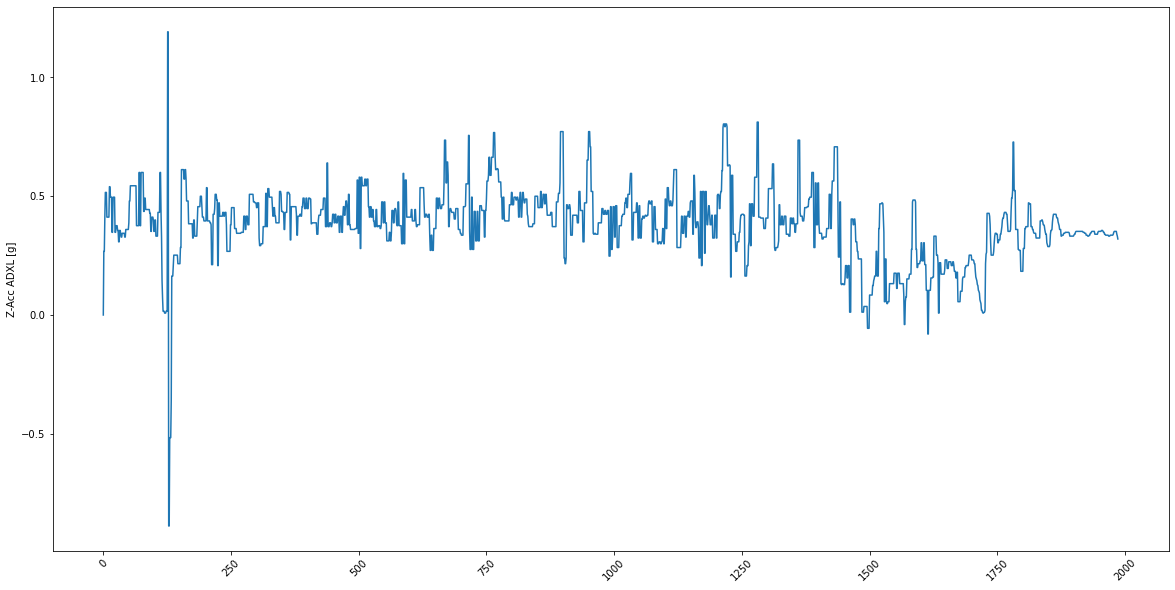

In [14]:
col_names = df.columns
#choose column number
col_name = col_names[5]
plt.figure(figsize=(20, 10))
df[col_name].plot()
plt.ylabel(col_name)
plt.xticks(rotation=45)
plt.show()

### Estimate sampling frequency

In [16]:
timeformat = '%Y-%m-%d %H:%M:%S.%f'

diffs = np.zeros(len(df['Date and Timestamp (string)'])-1)
for i in range(len(df['Date and Timestamp (string)'])-1):
    d1 = datetime.strptime(df.loc[i,'Date and Timestamp (string)'], timeformat)
    d2 = datetime.strptime(df.loc[i+1,'Date and Timestamp (string)'], timeformat)
    diff = (d2 - d1).total_seconds()
    diffs[i] = diff
mean_diff = diffs.mean()
dt = mean_diff
fs = int(1 / dt)
dt = 1 / fs
print("Sampling frequency is approximately {} Hz (dt = {} s)".format(fs, dt))

Sampling frequency is approximately 118 Hz (dt = 0.00847457627118644 s)


### Remove trend (drift) from the data

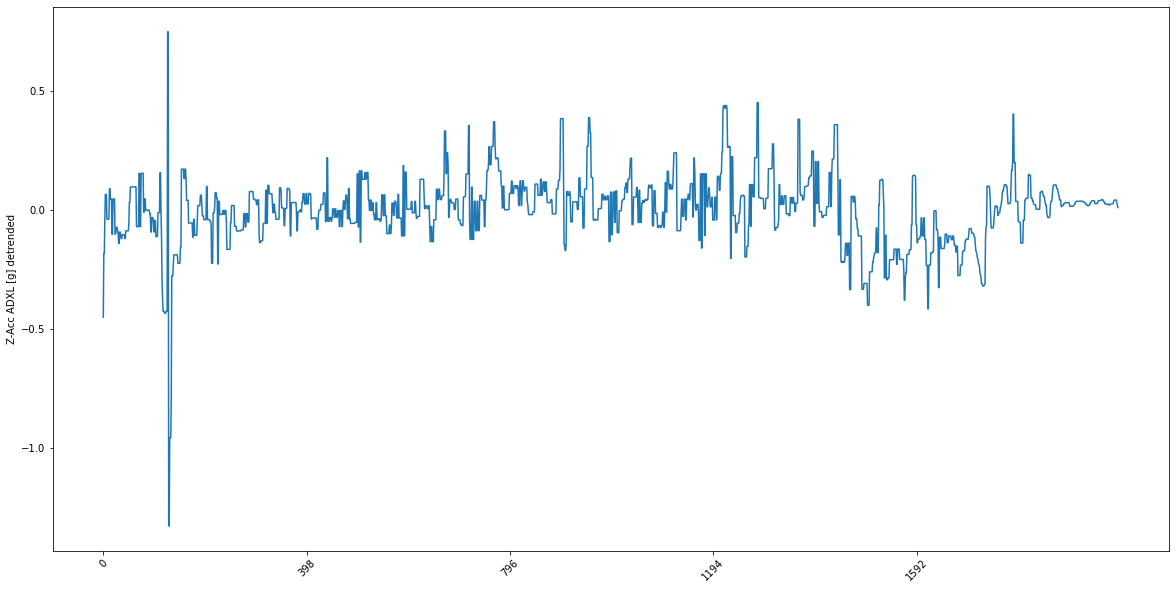

In [17]:
t = df.index
data = df[col_name].values
data = scipy.signal.detrend(data)

plt.figure(figsize=(20, 10))
plt.plot(data)
plt.ylabel(col_name + ' detrended')
plt.xticks(range(0,len(t)), t, rotation=45)
plt.locator_params(nbins=5, axis='x')
plt.show()

### Spectrum of the signal

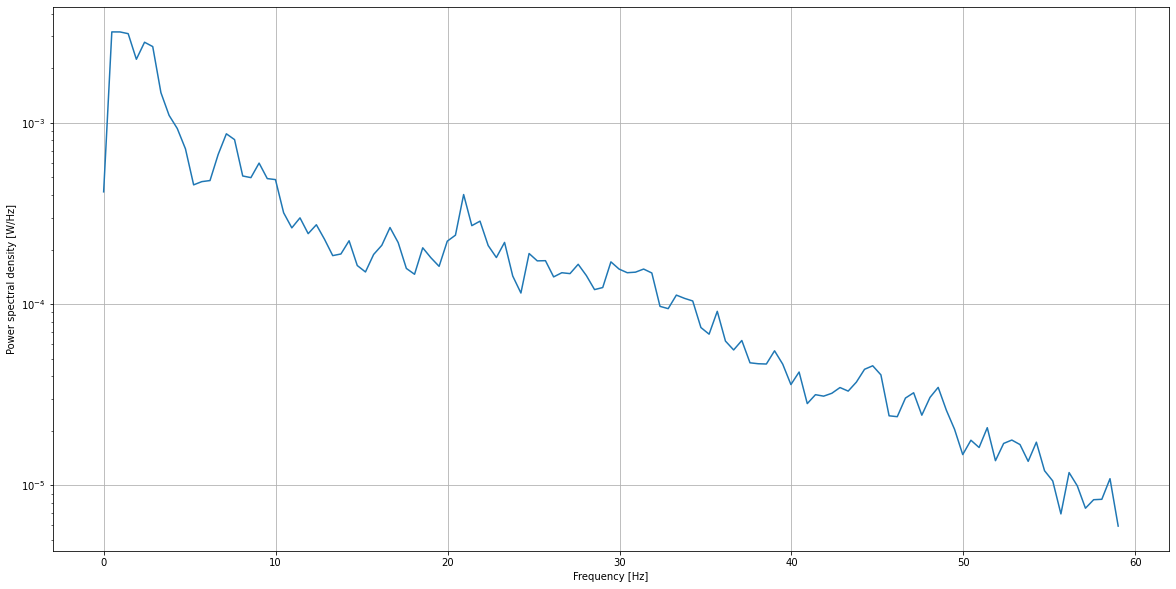

In [18]:
# default matlab parameters
nblock = len(data) // 8  # window size of Short Time Fourier Transform
overlap = nblock // 2  # overlap between windows
win = scipy.signal.windows.hamming(nblock, True)

f, Pxxf = scipy.signal.welch(data, fs, window=win, noverlap=overlap, nfft=nblock, return_onesided=True)

plt.figure(figsize=(20, 10))
plt.semilogy(f, Pxxf, '-')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power spectral density [W/Hz]')
plt.grid()
plt.show()

### Downsampling without artifacts

In structure health monitoring, we usually downsample the signal to study the frequencies of interest more closely. The following code implements a downsampling without [artifacts](https://en.wikipedia.org/wiki/Aliasing). The code can be replaced by the ```scipy.signal.decimate``` function. This function uses a different filter, and will yield different results to this code. 

#### Design filter (chebyshev type 2)

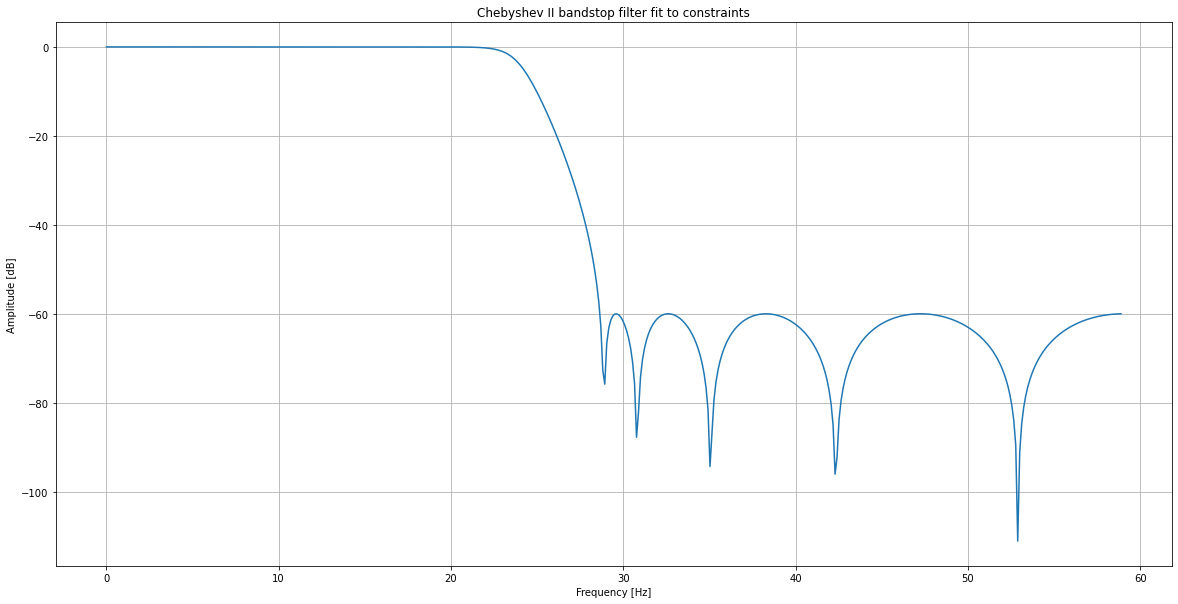

In [19]:
# Digital filter design: select which frequencies you want to cut-off
fp1 = 20 # start of transition band originaly = 15
fp2 = 30 # end of transition band originally = 30
gpass = 0.01 # maximum attenuation before transition 0.01
gstop = 60 # minimum attenuation after transition
[N, wn] = scipy.signal.cheb2ord(fp1, fp2, gpass, gstop, fs=fs)
sos = scipy.signal.cheby2(N, gstop, wn, btype='low', output='sos', fs=fs)

plt.figure(figsize=(20, 10))
w, h = scipy.signal.sosfreqz(sos)
plt.plot(w / np.pi * fs / 2, 20 * np.log10(abs(h)))
plt.title('Chebyshev II bandstop filter fit to constraints')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude [dB]')
plt.grid(which='both', axis='both')

#### Apply filter and Downsample (Downsampling not always performed - see report!)

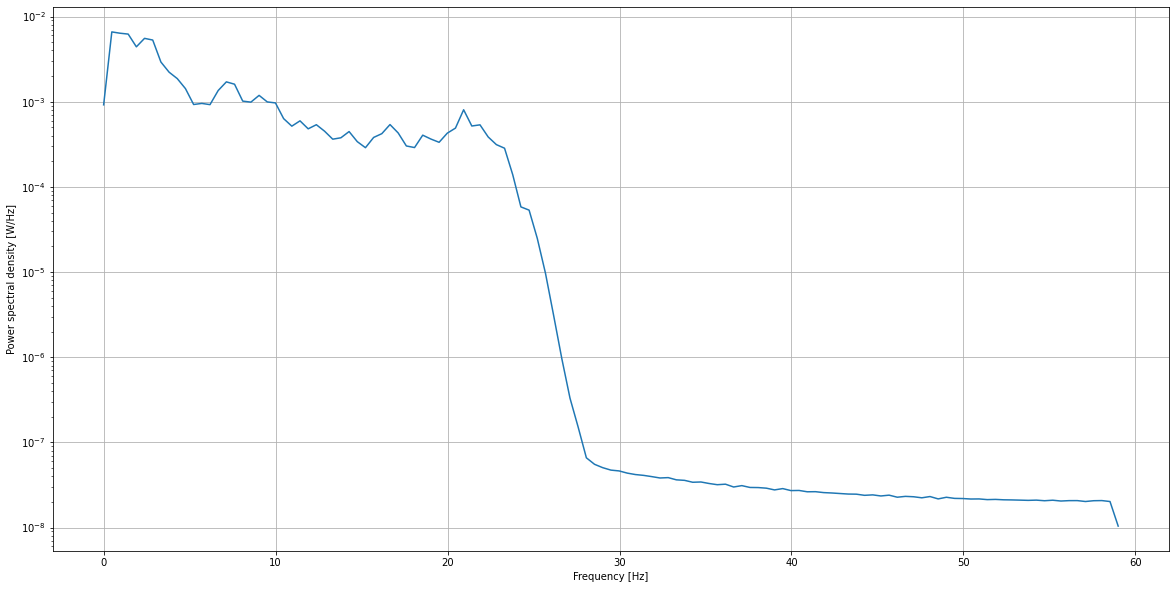

In [20]:
downsample = 2
fs_d = fs / downsample
dt_d = 1 / fs_d

#Filtering Chebyshev
filtered = scipy.signal.sosfilt(sos, data)
# Downsampling (not always performed!)
filtered_ds = filtered[::downsample]

f, Pxxf = scipy.signal.welch(filtered, fs_d, window=win, noverlap=overlap, nfft=nblock, return_onesided=True)

plt.figure(figsize=(20, 10))
plt.semilogy(f*2, Pxxf, '-')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power spectral density [W/Hz]')
plt.grid()
plt.show()

Text(0.5, 0, 'Rownumber in dataset')

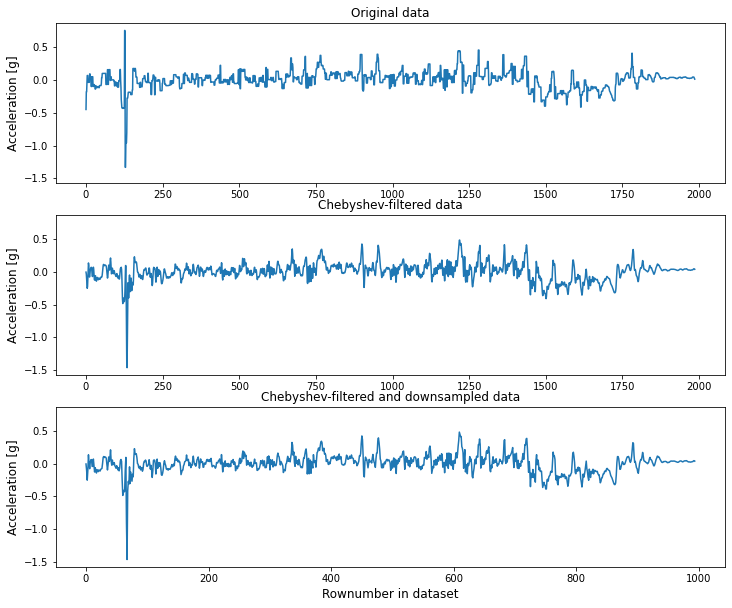

In [21]:
#Making effect of downsampling and filtering visible through plotting
fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharey=True)
ax1 = axs[0]
ax1.title.set_text('Original data')
ax1.plot(data)
ax1.set_ylabel('Acceleration [g]', fontsize=12)
ax2 = axs[1]
ax2.title.set_text('Chebyshev-filtered data')
ax2.plot(filtered)
ax2.set_ylabel('Acceleration [g]', fontsize=12)
ax3 = axs[2]
ax3.title.set_text('Chebyshev-filtered and downsampled data')
ax3.plot(filtered_ds)
ax3.set_ylabel('Acceleration [g]', fontsize=12)
ax3.set_xlabel('Rownumber in dataset', fontsize=12)


## Saving preprocessed data to CSV file again

In [2]:
#ATTENTION: Apply processing on each column first and write to dataframe then!
#Be sure to use the correct line corresponding to the input column!

In [912]:
x=filtered
df['X-Acc ADXL [g]']=x

In [929]:
y=filtered
df['Y-Acc ADXL [g]']=y

In [938]:
z=filtered
df['Z-Acc ADXL [g]']=z

In [942]:
#printing for double checking before saving
df

,Unnamed: 0,Date and Timestamp (string),Timestamp (float),X-Acc ADXL [g],Y-Acc ADXL [g],Z-Acc ADXL [g]
0,0,2022-05-17 11:12:51.874943,1.652779e+09,0.000800,-0.001465,-0.002147
1,1,2022-05-17 11:12:51.882777,1.652779e+09,0.004145,-0.009354,-0.012399
2,2,2022-05-17 11:12:51.890615,1.652779e+09,0.012993,-0.031282,-0.038212
3,3,2022-05-17 11:12:51.898443,1.652779e+09,0.030488,-0.071190,-0.080428
4,4,2022-05-17 11:12:51.906276,1.652779e+09,0.058290,-0.121412,-0.126378
...,...,...,...,...,...,...
2217,2217,2022-05-17 11:13:10.553635,1.652779e+09,-0.215695,0.038028,0.064642
2218,2218,2022-05-17 11:13:10.561909,1.652779e+09,-0.227383,0.082464,0.037960
2219,2219,2022-05-17 11:13:10.570188,1.652779e+09,-0.237484,-0.026190,0.033560
2220,2220,2022-05-17 11:13:10.578519,1.652779e+09,-0.241372,-0.131967,0.064456


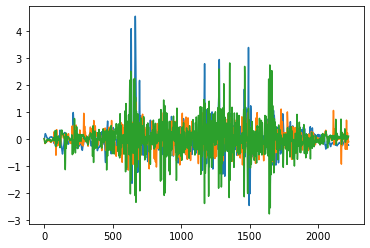

In [943]:
#plotting for double checking before saving
plt.plot(df['X-Acc ADXL [g]'])
plt.plot(df['Y-Acc ADXL [g]'])
plt.plot(df['Z-Acc ADXL [g]'])

In [944]:
#writing newly created dataframe with preprocessed data to CSV file
filepath = Path('/Users/konstantinmack/Documents/Studium/ETH/2. Semester/Master Project SMM (Konstruktiv)/04_Data Collection/170522/CSV/Vibration_ADXL_{}.csv'.format(n))  
df.to_csv(filepath)